# Figure 5: Host transcriptomics

DEG in the cervix and vagina between CST IV and non-CST IV communities

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import random
import matplotlib.patches as mpatches
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from Bio import Phylo
import os
import json
import requests

## Some constants, data analysis, and preprocessing

In [3]:
def proc_deseq_bw_groups(deseq_results, log2FC_cutoff=1.5, adj_pval_cutoff=0.05, base_mean_cutoff=10):
    ''' 
    A function to take the deseq results (as a pandas df), run ericher on the two groups, and return the deseq results with the pathways annotated.
    '''

    #take only significant genes
    deseq_results = deseq_results[deseq_results['padj'] <= adj_pval_cutoff]
    deseq_results = deseq_results[deseq_results['baseMean'] >= base_mean_cutoff]

    #parse out t1 genes
    t1_genes = deseq_results[deseq_results['log2FoldChange'] >= log2FC_cutoff]
    #parse out t2 genes
    t2_genes = deseq_results[deseq_results['log2FoldChange'] <= -1*log2FC_cutoff]

    #send the genes to enricher
    t1_genes = '\n'.join(list(t1_genes.gene.values))
    t2_genes = '\n'.join(list(t2_genes.gene.values))

    ENRICHR_URL = 'https://maayanlab.cloud/Enrichr/addList'

    description = 't1'
    payload = {
        'list': (None, t1_genes),
        'description': (None, description)
    }

    response = requests.post(ENRICHR_URL, files=payload)
    if not response.ok:
        raise Exception('Error analyzing gene list')

    data = json.loads(response.text)
    lid_t1 = data['userListId']


    description = 't2_genes'
    payload = {
        'list': (None, t2_genes),
        'description': (None, description)
    }

    response = requests.post(ENRICHR_URL, files=payload)
    if not response.ok:
        raise Exception('Error analyzing gene list')

    data = json.loads(response.text)
    lid_t2 = data['userListId']




    #get enrichment results
    ENRICHR_URL = 'https://maayanlab.cloud/Enrichr/enrich'
    query_string = '?userListId=%s&backgroundType=%s'
    gene_set_library = 'MSigDB_Hallmark_2020'


    response = requests.get(
        ENRICHR_URL + query_string % (lid_t1, gene_set_library)
    )
    if not response.ok:
        raise Exception('Error fetching enrichment results')

    t1_data = json.loads(response.text)
    t1_data = list(t1_data.values())[0]


    response = requests.get(
        ENRICHR_URL + query_string % (lid_t2, gene_set_library)
    )
    if not response.ok:
        raise Exception('Error fetching enrichment results')

    t2_data = json.loads(response.text)
    t2_data = list(t2_data.values())[0]



    #convert the results to a dataframe and merge with the deseq results to get pvalue and log fold changes
    t1_df = {'term':[], 'gene':[], 'pathway_rank':[]}
    for data in t1_data:
        term = data[1]
        rank = data[0]
        for gene in data[5]:
            t1_df['term'].append(term)
            t1_df['gene'].append(gene)
            t1_df['pathway_rank'].append(rank)

    t1_df = pd.DataFrame(t1_df)
    t1_df = pd.merge(t1_df, deseq_results, left_on='gene', right_on='gene', how='left')
    t1_df['abs_logFC'] = abs(t1_df['log2FoldChange'])

    t2_df = {'term':[], 'gene':[], 'pathway_rank':[]}
    for data in t2_data:
        term = data[1]
        rank = data[0]
        for gene in data[5]:
            t2_df['term'].append(term)
            t2_df['gene'].append(gene)
            t2_df['pathway_rank'].append(rank)

    t2_df = pd.DataFrame(t2_df)
    t2_df = pd.merge(t2_df, deseq_results, left_on='gene', right_on='gene', how='left')
    t2_df['abs_logFC'] = abs(t2_df['log2FoldChange'])

    #concat the two dataframes
    df = pd.concat([t1_df, t2_df])
    
    return df

In [4]:
#holds the colors for the different pathways
pathways_color_dict = {}
def rand_color():
    return "#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)])

pathways_color_dict = {
    'Epithelial Mesenchymal Transition': '#E6194B',  # Red
    'Complement': '#3CB44B',  # Green
    'Hypoxia': '#FFE119',  # Yellow
    'Estrogen Response Early': '#4363D8',  # Blue
    'p53 Pathway': '#F58231',  # Orange
    'heme Metabolism': '#911EB4',  # Purple
    'Estrogen Response Late': '#42D4F4',  # Cyan
    'mTORC1 Signaling': '#F032E6',  # Magenta
    'TNF-alpha Signaling via NF-kB': '#BFEF45'  # Lime
}
is_cstIV_colors = {True:'#6E7B82', False:'#FF6B35'}
is_cstIV_cmap = matplotlib.colors.ListedColormap(is_cstIV_colors.values())


In [6]:
#read in DEG
cervix_results = pd.read_csv('./fig5_datasets/mmtm_mt_host_genes_deseq2_isCSTIV_cervix.csv').rename(columns={'Unnamed: 0':'gene'})
vagina_results = pd.read_csv('./fig5_datasets/mmtm_mt_host_genes_deseq2_isCSTIV_vagina.csv').rename(columns={'Unnamed: 0':'gene'})

cervix_results['-log10_p'] = -1*np.log10(cervix_results['pvalue'])
cervix_results['sig'] = (cervix_results['padj'] <= 0.05 )

vagina_results['-log10_p'] = -1*np.log10(vagina_results['pvalue'])
vagina_results['sig'] = (vagina_results['padj'] <= 0.05 )

cervix_results_enrichr = proc_deseq_bw_groups(cervix_results, log2FC_cutoff=1.5)
vagina_results_enrichr = proc_deseq_bw_groups(vagina_results,log2FC_cutoff=1.5)

In [7]:
# note which pathways to highlight on the volcano plot and generate colors for them
pathways_annot_count = 3 # number of pathways to show for each condition
cervix_results_enrichr = cervix_results_enrichr[cervix_results_enrichr['pathway_rank'] <= pathways_annot_count]
vagina_results_enrichr = vagina_results_enrichr[vagina_results_enrichr['pathway_rank'] <= pathways_annot_count]

## Make Figure Layout

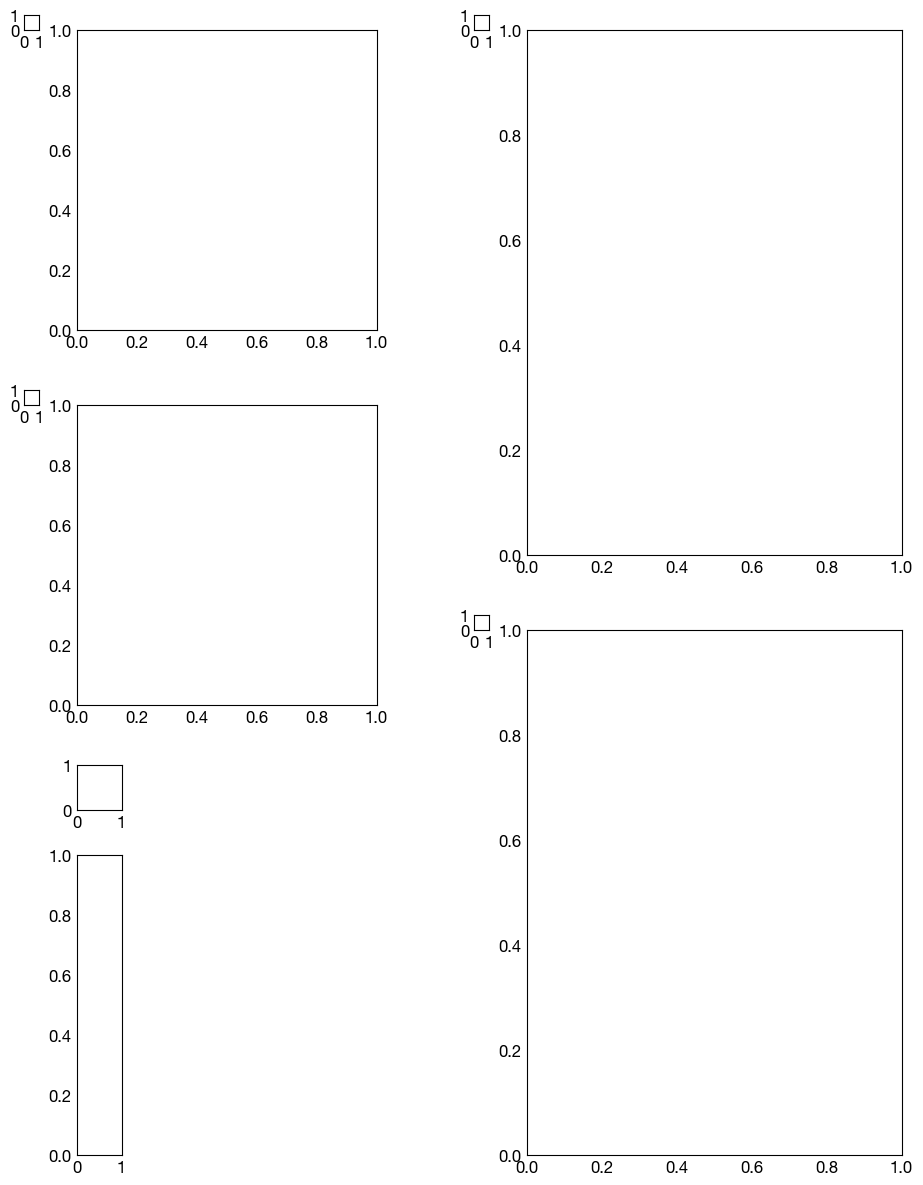

In [10]:
# figure size
WIDTH = 15
HEIGHT = 15

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))


### add the axes

# cervix DEG
ax1 = fig.add_axes([0.35, 0.45, 0.25, 0.35])

# vagina DEG
ax2 = fig.add_axes([0.35, 0.05, 0.25, 0.35])

# cervix PCA
ax3 = fig.add_axes([0.05, 0.6, 0.2, 0.2])

# vagina PCA
ax4 = fig.add_axes([0.05, 0.35, 0.2, 0.2])

# legends
func_legend_ax = fig.add_axes([0.05, 0.05, 0.03, 0.2])
pca_legend_ax = fig.add_axes([0.05, 0.28, 0.03, 0.03])

# axes for figure labels
a_ax = fig.add_axes([0.015, 0.8, 0.01, 0.01])
b_ax = fig.add_axes([0.015, 0.55, 0.01, 0.01])
c_ax = fig.add_axes([0.315, 0.8, 0.01, 0.01])
d_ax = fig.add_axes([0.315, 0.40, 0.01, 0.01])

## Volcano Plots

In [11]:
axs = [ax1, ax2]

#plot the cervix DEG
ax=axs[0]
sns.scatterplot(data=cervix_results, x='log2FoldChange', y='-log10_p', hue='sig', palette={True:'#b4b6b8', False:'#e1e3e6'}, s=50, ax=ax, alpha=0.25, linewidth=0)
sns.scatterplot(data=cervix_results_enrichr, x='log2FoldChange', y='-log10_p', hue='term', palette=pathways_color_dict, s=50, ax=ax, alpha=1, linewidth=1, edgecolor='black')
ax.set_title('Cervix DEG: CST-IV vs Non-CST-IV')
ax.set_xlabel('$log_{2}FC$')
ax.set_ylabel('$-log_{10}(p-value)$')
ax.text(x=2, y=0, s='↑CST IV', fontsize=10, ha='left', fontfamily='Arial')
ax.text(x=-3, y=0, s='↑non-CST IV', fontsize=10, ha='right', fontfamily='Arial')

#plot the vaginal DEG
ax=axs[1]
sns.scatterplot(data=vagina_results, x='log2FoldChange', y='-log10_p', hue='sig', palette={True:'#b4b6b8', False:'#e1e3e6'}, s=50, ax=ax, alpha=0.25, linewidth=0)
sns.scatterplot(data=vagina_results_enrichr, x='log2FoldChange', y='-log10_p', hue='term', palette=pathways_color_dict, s=50, ax=ax, alpha=1, linewidth=1, edgecolor='black')
ax.set_title('Vaginal DEG: CST-IV vs Non-CST-IV')
ax.set_xlabel('$log_{2}FC$')
ax.set_ylabel('$-log_{10}(p-value)$')
ax.text(x=1.75, y=0, s='↑CST IV', fontsize=10, ha='left', fontfamily='Arial')
ax.text(x=-3, y=0, s='↑non-CST IV', fontsize=10, ha='right', fontfamily='Arial')

for ax in axs:
    ax.get_legend().remove()
    ax.axvline(x=0, color='gray', alpha=0.4, linestyle='--')
    

## PCAs

In [12]:
#read in gene count data
ht_counts = pd.read_csv('./fig5_datasets/MMTM_host_featureCounts_0520204.csv').fillna(0)

#rename columns
filt_col = ['Geneid', 'Length']
#filt_col = ['Geneid']
filt_col.extend([c for c in ht_counts.columns if c.startswith('MT_')])
ht_counts = ht_counts[filt_col]
ht_counts = ht_counts.rename(columns=lambda x: x.split('_')[1] if x.startswith('MT_MTM') and x.endswith('_ZYMO') else x)
ht_counts

#filter out samples with few reads
column_sums = ht_counts.iloc[:, 2:].sum()
filtered_columns = column_sums[column_sums >= 5E6].index
ht_counts = ht_counts.loc[:, list(ht_counts.columns[:2]) + list(filtered_columns)]


#correct for gene length
ht_counts = ht_counts[ht_counts['Length'] > 500]
glcorr_data = ht_counts[ht_counts.columns[2:]].div(ht_counts['Length'],axis=0)
ht_counts = pd.concat([ht_counts[ht_counts.columns[0:2]],glcorr_data],axis=1)

#convert to tpm
corr_counts = ht_counts.iloc[:,2:].div(ht_counts.iloc[:,2:].sum()/1E6, axis=1)
ht_counts = pd.concat([ht_counts[ht_counts.columns[0:2]], corr_counts], axis=1)
ht_counts = ht_counts.drop('Length', axis=1)

#remove genes with low average tpm
ht_counts = ht_counts[ht_counts.mean(axis=1) > 5]

#center, scale, and transpose
ht_counts.iloc[:,1:] = scale(ht_counts.iloc[:,1:], axis=0)
ht_counts = ht_counts.set_index('Geneid').T

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_16830/20843301.py:29: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  ht_counts = ht_counts[ht_counts.mean(axis=1) > 5]


In [13]:
#read in sample metadata
sample_metadata = pd.read_csv('./common/mmtm_metadata.csv')

#concat cst infomation
cst_info = pd.read_csv('./common/mmtm_cst_assignments_taxa_corr.csv')
sample_metadata = pd.merge(sample_metadata, cst_info, left_on='IGS LABEL', right_on='sampleID', how='outer')

#group the cst assignments
sample_metadata['isCSTIV'] = sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])

In [14]:
# plot the cervical PCA
filt_ht_counts = sample_metadata[sample_metadata['Cervix/Vagina'] == 'C']['IGS LABEL'].values
filt_ht_counts = ht_counts[ht_counts.index.isin(filt_ht_counts)]

#do the pca
pca_emb = PCA(n_components=5)
ht_pca_filt = pd.DataFrame(pca_emb.fit_transform(filt_ht_counts))
ht_pca_filt['location'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Cervix/Vagina'].values[0])
ht_pca_filt['tp'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Timepoint'].values[0])
ht_pca_filt['cst'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['CST'].values[0])
ht_pca_filt['isCSTIV'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['isCSTIV'].values[0])
var_exp = pca_emb.explained_variance_ratio_
var_exp = [round(n, 3) for n in var_exp]

#plot
ax = ax3
sns.scatterplot(data=ht_pca_filt, x=0, y=1, ax=ax, hue='isCSTIV', palette=is_cstIV_colors,s=30, legend=False, edgecolor='black')
ax.set_xlabel('PCA-1(' + '{:.2f}'.format(var_exp[0]*100) + '%)')
ax.set_ylabel('PCA-2(' + '{:.2f}'.format(var_exp[1]*100) + '%)')
ax.set_title('Cervix')

Text(0.5, 1.0, 'Cervix')

In [15]:
# plot the vaginal PCA
filt_ht_counts = sample_metadata[sample_metadata['Cervix/Vagina'] == 'V']['IGS LABEL'].values
filt_ht_counts = ht_counts[ht_counts.index.isin(filt_ht_counts)]

#do the pca
pca_emb = PCA(n_components=5)
ht_pca_filt = pd.DataFrame(pca_emb.fit_transform(filt_ht_counts))
ht_pca_filt['location'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Cervix/Vagina'].values[0])
ht_pca_filt['tp'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['Timepoint'].values[0])
ht_pca_filt['cst'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['CST'].values[0])
ht_pca_filt['isCSTIV'] = pd.Series(filt_ht_counts.index).apply(lambda x: sample_metadata[sample_metadata['IGS LABEL'] == x]['isCSTIV'].values[0])
var_exp = pca_emb.explained_variance_ratio_
var_exp = [round(n, 3) for n in var_exp]

#plot
ax = ax4
sns.scatterplot(data=ht_pca_filt, x=0, y=1, ax=ax, hue='isCSTIV', palette=is_cstIV_colors,s=30, legend=False, edgecolor='black')
ax.set_xlabel('PCA-1(' + '{:.2f}'.format(var_exp[0]*100) + '%)')
ax.set_ylabel('PCA-2(' + '{:.2f}'.format(var_exp[1]*100) + '%)')
ax.set_title('Vagina')

Text(0.5, 1.0, 'Vagina')

## Add Legends

In [16]:
# adding functions legend
patch_list = []

for p, c in pathways_color_dict.items():
    patch_list.append(mpatches.Patch(color=c,label=p))

patch_list.extend([mpatches.Patch(color='white',label=' ', alpha=0), mpatches.Patch(color='#b4b6b8',label='FDR ≤ 0.05', alpha=0.25), mpatches.Patch(color='#e1e3e6',label='FDR > 0.05', alpha=0.25)])
func_legend_ax.legend(handles=patch_list,ncol=1, loc=(0, 0.2), bbox_to_anchor=(0,0,1,1), fontsize=10, frameon=False)
func_legend_ax.set_axis_off()

# adding PCA legend
cbar = matplotlib.colorbar.ColorbarBase(pca_legend_ax, cmap=is_cstIV_cmap, orientation = 'vertical',ticklocation='right',ticks=[0.25,0.75])
cbar.ax.set_yticklabels(['CST IV','non-CST IV'],fontsize=10)
pca_legend_ax.set_ylim(1,0)

(1.0, 0.0)

## Add Figure Labels

In [17]:
labels = ['A', 'B', 'C', 'D']
for ax in [a_ax, b_ax, c_ax, d_ax]:
    ax.text(x=0,y=0,s=labels.pop(0),fontsize=24, weight='bold')
    ax.set_axis_off()

## Save Figure

In [18]:
fig.savefig('fig5_V2.pdf', format='pdf', bbox_inches='tight')

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
